In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv('/content/placement.csv')

In [34]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [35]:
df.shape

(100, 4)


## Steps

* Preprocess + EDA + Feature Selection
* Extract input and output cols
* Scale the values
* Train test split
* Train the model
* Evaluate the model/model selection
* Deploy the model

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [38]:
df = df.iloc[:,1:]

In [39]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


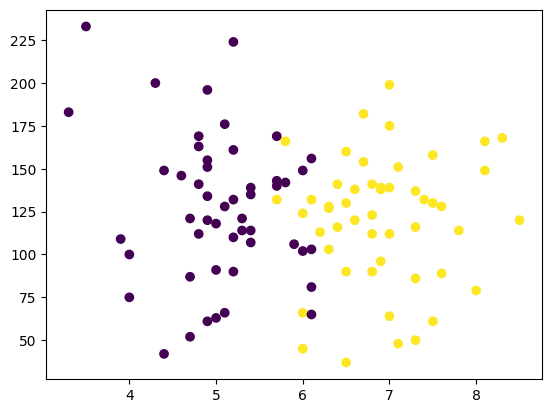

In [42]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

####  Extract input and output cols

In [43]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [44]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [45]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


#### Train test split

In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [52]:
x_train

,cgpa,iq
3,7.4,132.0
94,4.7,52.0
0,6.8,123.0
76,4.9,155.0
39,4.6,146.0
...,...,...
71,6.1,132.0
98,6.3,103.0
49,5.4,135.0
87,5.7,132.0


In [53]:
x_test

,cgpa,iq
35,6.8,90.0
85,5.8,166.0
5,7.1,48.0
18,4.0,100.0
42,7.6,89.0
16,5.2,224.0
15,5.1,176.0
83,7.5,130.0
78,6.1,81.0
19,5.2,132.0


In [54]:
y_train

,placement
3,1
94,0
0,1
76,0
39,0
...,...
71,1
98,1
49,0
87,1


In [55]:
y_test

,placement
35,1
85,1
5,1
18,0
42,1
16,0
15,0
83,1
78,0
19,0


#### Scale the values

In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
scaler = StandardScaler()

In [58]:
x_train = scaler.fit_transform(x_train)

In [59]:
x_train

array([[ 1.24229654,  0.21924648],
       [-1.12909434, -1.86330586],
       [ 0.71532079, -0.01504066],
       [-0.95343576,  0.81798028],
       [-1.21692363,  0.58369314],
       [ 1.33012583,  0.89607599],
       [-0.5142893 ,  0.40146981],
       [-0.60211859, -0.24932779],
       [ 0.89097937,  1.33861837],
       [ 0.80315008, -0.71790207],
       [-0.86560646, -0.84806159],
       [-0.25080142,  0.42750172],
       [ 1.15446725, -1.91536967],
       [ 0.01268645, -0.56171065],
       [ 1.59361371, -0.24932779],
       [ 1.15446725, -0.97822111],
       [ 1.76927229, -1.16044445],
       [-1.48041151,  1.98941598],
       [-1.04126505, -0.3013916 ],
       [ 0.89097937,  1.96338407],
       [-2.18304584,  2.84846882],
       [-0.95343576, -1.62901872],
       [-0.60211859, -0.06710446],
       [-0.77777717,  0.11511887],
       [ 0.36400362,  0.45353362],
       [-0.25080142,  1.18242694],
       [-0.5142893 , -0.24932779],
       [ 0.45183291, -2.25378443],
       [ 0.71532079,

In [60]:
x_test = scaler.transform(x_test)

In [61]:
x_test

array([[ 0.71532079, -0.8740935 ],
       [-0.16297213,  1.10433123],
       [ 0.97880866, -1.96743348],
       [-1.74389938, -0.61377445],
       [ 1.41795512, -0.9001254 ],
       [-0.68994788,  2.61418168],
       [-0.77777717,  1.36465027],
       [ 1.33012583,  0.16718267],
       [ 0.10051575, -1.10838064],
       [-0.68994788,  0.21924648]])

#### Train the model

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
clf = LogisticRegression()

In [64]:
# train model
clf.fit(x_train,y_train)

LogisticRegression()

#### Evaluate the model/model selection

In [73]:
y_pred = clf.predict(x_test)

In [74]:
y_test # to see actual data

,placement
35,1
85,1
5,1
18,0
42,1
16,0
15,0
83,1
78,0
19,0


In [75]:
# cheacking accuracy score
from sklearn.metrics import accuracy_score

In [76]:
accuracy_score(y_test,y_pred)

0.8

In [77]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

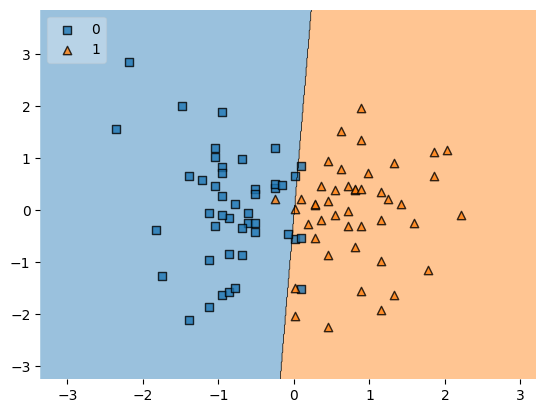

In [79]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [80]:
import pickle

In [81]:
pickle.dump(clf,open('model.pkl','wb'))